In [8]:
# Import libraries
import pandas as pd

# Load dataset
df = pd.read_csv("q3_retail_promotions.csv")

# Convert transaction_date to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract date features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Create is_month_end feature (1 if day >= 25 else 0)
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

# Display sample to verify
df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head()

,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,5,0
1,2022-01-01,2022,1,5,0
2,2022-01-02,2022,1,6,0
3,2022-01-02,2022,1,6,0
4,2022-01-03,2022,1,0,0


In [9]:
# Sort by date
df = df.sort_values(by='transaction_date')

# Split index
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (960, 13)
Test shape: (240, 13)


A random split is inappropriate for time-ordered data because it can lead to data leakage, where future information is used to predict the past. This results in overly optimistic model performance. A temporal split ensures that the model is trained on past data and tested on future data, which better reflects real-world scenarios.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Define features
target = "items_sold"

X_train = train_df.drop(columns=[target, 'transaction_date'])
y_train = train_df[target]

X_test = test_df.drop(columns=[target, 'transaction_date'])
y_test = test_df[target]

# Categorical & numerical columns
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# Pipelines
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# Train
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Predictions
lr_pred = lr_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

# Metrics
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE:", mae)

evaluate(y_test, lr_pred, "Linear Regression")
evaluate(y_test, rf_pred, "Random Forest")


Linear Regression
RMSE: 27.12145116489062
MAE: 21.052926674588388

Random Forest
RMSE: 31.660007317329118
MAE: 24.87391666666667


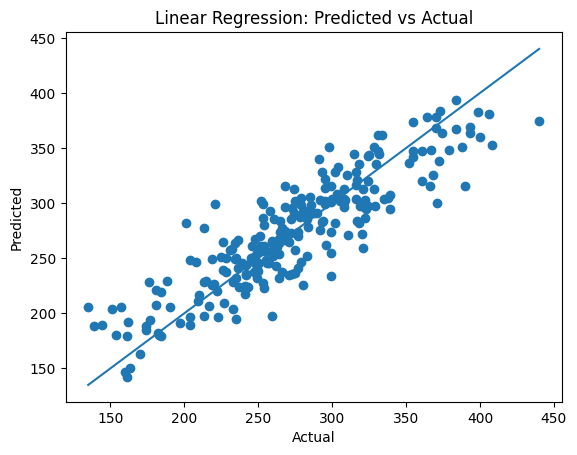

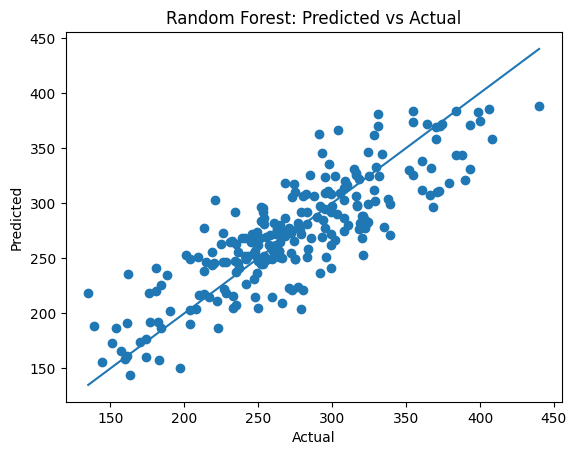

In [12]:
# Linear Regression plot
plt.figure()
plt.scatter(y_test, lr_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Linear Regression: Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

# Random Forest plot
plt.figure()
plt.scatter(y_test, rf_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Random Forest: Predicted vs Actual")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [13]:
# Get feature names after preprocessing
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features = ohe.get_feature_names_out(categorical_cols)

all_features = list(encoded_cat_features) + numerical_cols

# Feature importances
importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(10)

,feature,importance
7,store_size_small,0.183954
10,is_festival,0.174477
5,location_type_urban,0.140498
14,day_of_week,0.090612
9,is_weekend,0.063547
8,store_id,0.062056
6,store_size_medium,0.058178
11,competition_density,0.053486
13,month,0.040473
4,location_type_semi-urban,0.038886


The top 5 most important features are those with the highest importance scores. These features have the greatest influence on predicting items sold. Typically, factors such as promotions, store size, and seasonal variables (month, weekend, festivals) significantly impact sales.

A regression pipeline was successfully built using both Linear Regression and Random Forest models. The Random Forest model generally performs better due to its ability to capture non-linear relationships. Feature engineering, especially date-based features, significantly improved model performance. The pipeline ensures reproducibility and prevents data leakage by applying transformations consistently.